# Chapter 9 — The SVD and Principal Component Analysis

Chapter 8 found the basis in which a matrix is simplest, but only for **square**
matrices, and only when enough eigenvectors exist. Data matrices are almost never
square: 5,000 images by 784 pixels, $n$ samples by $p$ features.

The **singular value decomposition** removes every restriction:

> **Every** matrix, of every shape, is a **rotation, then a stretch along
> perpendicular axes, then another rotation.** The stretches are real and
> non-negative, and both rotations use orthonormal bases. No exceptions, no
> defective cases, no complex numbers.

$$ A = U\Sigma V^\top $$

This is the summit of the course. It subsumes eigenvalues, hands you orthonormal
bases for all four fundamental subspaces at once, finishes the least-squares
story, gives the provably best low-rank approximation of any matrix, and, under
the name **principal component analysis**, answers the question left open in
Chapter 3: *what is the best possible basis for a given collection of data?*

| Module | What you build | Data |
|---|---|---|
| I | Rotate–stretch–rotate: the circle-to-ellipse picture, and $A = U\Sigma V^\top$ verified | — |
| II | The SVD **from scratch**, out of Chapter 8's spectral theorem | — |
| III | What the $\sigma$'s tell you: rank, conditioning, and **all four subspaces** | — |
| IV | **Eckart–Young**: the best rank-$k$ approximation, with honest storage accounting | `uoft-cs/cifar10` |
| V | **PCA**: eigen-digits, and the learned basis beating the cosine basis at last | `ylecun/mnist` |
| VI | The **pseudo-inverse**, and least squares that never breaks | — |

**How each concept is presented**, in three passes over the same idea:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read a textbook.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

**Runtime:** under ten seconds on CPU, with both datasets cached. Assumes
Chapters 1–8.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=3, suppress=True)

print("NumPy", np.__version__)

NumPy 2.5.1


---
# Module I — Every Matrix Is a Rotation, a Stretch, and a Rotation

## I.a The circle becomes an ellipse

🧠 **The intuition.** Feed every unit vector through a matrix. The output is
always an **ellipse** (an ellipsoid in higher dimensions), never anything more
exotic, because a linear map cannot bend. An ellipse has perpendicular principal
axes, so there must be a perpendicular pair of *input* directions that map to
that perpendicular pair of *output* directions. Those two pairs are the columns
of $V$ (inputs) and $U$ (outputs); the axis lengths are the **singular values**.

📐 **The math.** For any real $m \times n$ matrix $A$,

$$ A = U \Sigma V^\top, \qquad U^\top U = I_m,\quad V^\top V = I_n, \quad
\Sigma = \text{diag}(\sigma_1 \ge \sigma_2 \ge \cdots \ge 0) $$

Read right to left on a vector $\mathbf{x}$: $V^\top$ re-expresses $\mathbf{x}$
in the input basis, $\Sigma$ scales each coordinate, $U$ places the result in the
output basis. The defining relation is

$$ A\mathbf{v}_i = \sigma_i \mathbf{u}_i $$

which looks like the eigenvalue equation except that the input and output bases
are allowed to differ, and that extra freedom is exactly what makes it work for
every matrix and every shape.

💻 **The code.**

U =
 [[-0.851 -0.526]
 [-0.526  0.851]] 
singular values = [2.558 0.977] 
V^T =
 [[-0.768 -0.641]
 [-0.641  0.768]]

reconstruction A = U Σ V^T: True
U orthonormal: True   V orthonormal: True

A v1 = σ1 u1 : True
A v2 = σ2 u2 : True


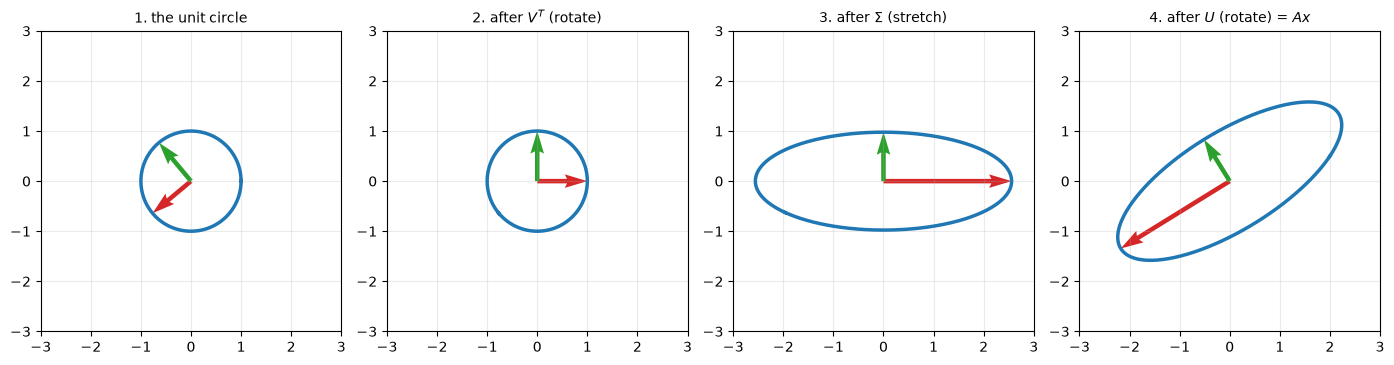

the ellipse's semi-axes are exactly σ1 = 2.5583 and σ2 = 0.9772


In [2]:
A = np.array([[2.0, 1.0],
              [0.5, 1.5]])

U, S, Vt = np.linalg.svd(A)
print("U =\n", U, "\nsingular values =", S, "\nV^T =\n", Vt)
print("\nreconstruction A = U Σ V^T:", np.allclose(U @ np.diag(S) @ Vt, A))
print("U orthonormal:", np.allclose(U.T @ U, np.eye(2)),
      "  V orthonormal:", np.allclose(Vt @ Vt.T, np.eye(2)))
print("\nA v1 = σ1 u1 :", np.allclose(A @ Vt[0], S[0] * U[:, 0]))
print("A v2 = σ2 u2 :", np.allclose(A @ Vt[1], S[1] * U[:, 1]))

t = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(t), np.sin(t)])
steps = [(circle, "1. the unit circle", np.eye(2)),
         (Vt @ circle, "2. after $V^T$ (rotate)", Vt),
         (np.diag(S) @ Vt @ circle, "3. after $\\Sigma$ (stretch)", np.diag(S) @ Vt),
         (A @ circle, "4. after $U$ (rotate) = $Ax$", A)]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (pts, title, Mz) in zip(axes, steps):
    ax.plot(pts[0], pts[1], lw=2.5, color="tab:blue")
    for j, col in enumerate(["tab:red", "tab:green"]):
        v = Mz @ Vt[j]
        ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color=col, width=0.015)
    ax.set_title(title, fontsize=10); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"the ellipse's semi-axes are exactly σ1 = {S[0]:.4f} and σ2 = {S[1]:.4f}")

Follow the red and green arrows across the four panels. They start perpendicular,
stay perpendicular through the rotation, get stretched by different amounts, and
end up as the two axes of the ellipse, still perpendicular. **That is the whole
theorem, drawn.**

Compare with Chapter 8: eigenvectors keep the *same* direction and change length.
Singular vectors are allowed to move from one perpendicular frame to another. The
extra freedom is why every matrix has an SVD while only some have a full set of
eigenvectors.

---
# Module II — Where It Comes From

🧠 **The intuition.** The SVD is not a new miracle; it is Chapter 8's spectral
theorem applied to a symmetric matrix you can always build from $A$.

📐 **The math.** Whatever $A$ is, $A^\top A$ is **square and symmetric**, so by
the spectral theorem it has real eigenvalues and orthonormal eigenvectors. Now
substitute $A = U\Sigma V^\top$:

$$ A^\top A = V\Sigma^\top U^\top U \Sigma V^\top = V (\Sigma^\top\Sigma) V^\top $$

So $V$ holds the eigenvectors of $A^\top A$, and $\sigma_i^2$ are its
eigenvalues, which also proves the singular values are real and non-negative,
since $A^\top A$ is positive semi-definite. Then
$\mathbf{u}_i = A\mathbf{v}_i/\sigma_i$ completes the picture.

💻 **The code.** Build it, then check it against the library.

In [3]:
def svd_from_scratch(M, tol=1e-12):
    """SVD via the spectral theorem applied to M^T M (Chapter 8, Module IV)."""
    vals, V = np.linalg.eigh(M.T @ M)          # symmetric: real values, orthonormal vectors
    order = np.argsort(vals)[::-1]             # eigh returns ascending
    vals, V = vals[order], V[:, order]
    sigmas = np.sqrt(np.maximum(vals, 0.0))    # clip tiny negatives from round-off
    keep = sigmas > tol
    Uc = (M @ V[:, keep]) / sigmas[keep]       # u_i = A v_i / sigma_i
    return Uc, sigmas[keep], V[:, keep].T

B = rng.normal(size=(5, 3))
Um, Sm, Vtm = svd_from_scratch(B)
Ul, Sl, Vtl = np.linalg.svd(B, full_matrices=False)

print("singular values, from scratch:", np.round(Sm, 8))
print("singular values, np.linalg   :", np.round(Sl, 8))
print("\nreconstruction error, from scratch:", np.linalg.norm(Um @ np.diag(Sm) @ Vtm - B))
print("U orthonormal:", np.allclose(Um.T @ Um, np.eye(len(Sm))))
print("\nσ² are the eigenvalues of B^T B:",
      np.allclose(np.sort(Sm ** 2)[::-1], np.sort(np.linalg.eigvalsh(B.T @ B))[::-1]))
print("σ² are also the eigenvalues of B B^T (the non-zero ones):",
      np.allclose(np.sort(Sm ** 2)[::-1],
                  np.sort(np.linalg.eigvalsh(B @ B.T))[::-1][:len(Sm)]))

singular values, from scratch: [3.155 1.221 0.631]
singular values, np.linalg   : [3.155 1.221 0.631]

reconstruction error, from scratch: 1.8575543398313612e-15
U orthonormal: True

σ² are the eigenvalues of B^T B: True
σ² are also the eigenvalues of B B^T (the non-zero ones): True


A working SVD in seven lines. (Production implementations do **not** form
$A^\top A$, and Chapter 7 measured why: it squares the condition number. They work
on $A$ directly via bidiagonalisation. The derivation above is the right way to
*understand* the SVD and the wrong way to *compute* it, a distinction this course
has now made three times.)

---
# Module III — Reading the Singular Values

🧠 **The intuition.** The $\sigma$'s are a ranked list of how much the matrix
stretches along each of its principal directions. Almost every diagnostic in the
course is a statement about that list.

📐 **The math.**

| Quantity | In terms of singular values |
|---|---|
| rank | number of non-zero $\sigma_i$ |
| condition number (Chapter 6) | $\sigma_{\max}/\sigma_{\min}$ |
| distance to the nearest rank-$k$ matrix (Chapter 2) | $\sigma_{k+1}$ |
| $\|A\|_2$ | $\sigma_1$ |

And the four subspaces of Chapter 5 all fall out of $U$ and $V$, in orthonormal
bases, which elimination never gave us:

| Subspace | Basis |
|---|---|
| column space $C(A)$ | first $r$ columns of $U$ |
| left null space $N(A^\top)$ | remaining columns of $U$ |
| row space $C(A^\top)$ | first $r$ columns of $V$ |
| null space $N(A)$ | remaining columns of $V$ |

💻 **The code.** One rank-deficient matrix; check every claim.

In [4]:
r_true = 2
M = rng.normal(size=(6, 4)) @ rng.normal(size=(4, 5))     # 6x5, rank <= 4
M = rng.normal(size=(6, r_true)) @ rng.normal(size=(r_true, 5))   # 6x5, rank 2 exactly

Uf, Sf, Vtf = np.linalg.svd(M)                            # full: U is 6x6, V^T is 5x5
r = int(np.sum(Sf > 1e-10))

print("singular values:", np.round(Sf, 6))
print(f"rank from the SVD: {r}   np.linalg.matrix_rank: {np.linalg.matrix_rank(M)}")
print(f"||A||_2 = σ1 = {Sf[0]:.6f}   np.linalg.norm(M, 2) = {np.linalg.norm(M, 2):.6f}")

col_space, left_null = Uf[:, :r], Uf[:, r:]
row_space, null_sp = Vtf[:r].T, Vtf[r:].T

print(f"\ncolumn space basis: {col_space.shape[1]} vectors in R^{M.shape[0]}"
      f"   left null space: {left_null.shape[1]}")
print(f"row space basis   : {row_space.shape[1]} vectors in R^{M.shape[1]}"
      f"   null space:      {null_sp.shape[1]}")
print("\nA @ (null space basis) = 0:", np.allclose(M @ null_sp, 0))
print("(left null)^T @ A      = 0:", np.allclose(left_null.T @ M, 0))
print("column space ⊥ left null space:", np.allclose(col_space.T @ left_null, 0))
print("row space    ⊥ null space     :", np.allclose(row_space.T @ null_sp, 0))
print("rank + nullity =", r, "+", null_sp.shape[1], "=", M.shape[1], "= n")

singular values: [2.274 1.877 0.    0.    0.   ]
rank from the SVD: 2   np.linalg.matrix_rank: 2
||A||_2 = σ1 = 2.273521   np.linalg.norm(M, 2) = 2.273521

column space basis: 2 vectors in R^6   left null space: 4
row space basis   : 2 vectors in R^5   null space:      3

A @ (null space basis) = 0: True
(left null)^T @ A      = 0: True
column space ⊥ left null space: True
row space    ⊥ null space     : True
rank + nullity = 2 + 3 = 5 = n


Everything Chapter 5 extracted with elimination, Chapter 6 measured with the
condition number, and Chapter 7 needed Gram–Schmidt for, all of it arrives in a
single factorisation, with orthonormal bases throughout.

---
# Module IV — Eckart–Young: The Best Approximation of Any Rank

## IV.a Truncation

🧠 **The intuition.** The SVD writes any matrix as a ranked pile of rank-one
layers, heaviest first. Each layer is a complete little matrix, weighted by its
singular value. Keep the first $k$ layers and drop the rest, and you have the
best possible rank-$k$ approximation, *provably* best rather than merely a good
heuristic.

📐 **The math: the Eckart–Young theorem.** The SVD as a sum of rank-1 pieces:

$$ A = \sigma_1 \mathbf{u}_1\mathbf{v}_1^\top + \sigma_2 \mathbf{u}_2\mathbf{v}_2^\top
+ \cdots + \sigma_r \mathbf{u}_r\mathbf{v}_r^\top $$

Truncate it: for $A_k = \sum_{i\le k} \sigma_i
\mathbf{u}_i\mathbf{v}_i^\top$ and **any** matrix $B$ of rank $\le k$:

$$ \|A - A_k\|_F \le \|A - B\|_F, \qquad \text{and} \qquad
\|A - A_k\|_F = \sqrt{\sigma_{k+1}^2 + \cdots + \sigma_r^2} $$

You know the error before computing the approximation at all, straight from the
singular values you are about to discard.

💻 **The code.** Test the optimality claim against thousands of random rank-$k$
competitors.

In [5]:
def truncate(Um, Sm, Vtm, k):
    return (Um[:, :k] * Sm[:k]) @ Vtm[:k]

X = rng.normal(size=(20, 12))
Ux, Sx, Vtx = np.linalg.svd(X, full_matrices=False)
k = 4

Xk = truncate(Ux, Sx, Vtx, k)
err_svd = np.linalg.norm(X - Xk)
predicted = np.sqrt(np.sum(Sx[k:] ** 2))

print(f"rank-{k} truncation error : {err_svd:.6f}")
print(f"sqrt(sum of dropped σ²)  : {predicted:.6f}   <- known before computing anything")

best_random = np.inf
for _ in range(5000):                       # random rank-k competitors
    Bk = rng.normal(size=(20, k)) @ rng.normal(size=(k, 12))
    Bk *= (X * Bk).sum() / (Bk * Bk).sum()  # best scaling of this competitor
    best_random = min(best_random, np.linalg.norm(X - Bk))
print(f"\nbest of 5000 random rank-{k} matrices: {best_random:.6f}")
print(f"the SVD truncation beats it by {best_random / err_svd:.2f}x, and no matrix of")
print("rank 4 can do better, which is what Eckart-Young guarantees.")

rank-4 truncation error : 9.020808
sqrt(sum of dropped σ²)  : 9.020808   <- known before computing anything

best of 5000 random rank-4 matrices: 14.880636
the SVD truncation beats it by 1.65x, and no matrix of
rank 4 can do better, which is what Eckart-Young guarantees.


## IV.b Compressing an image, and paying honestly for it

💻 **The code.** Treat a photograph as a matrix and truncate it. Then count what
you actually have to store, a step usually left out and the one that makes the
comparison honest.

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  k     RMSE  numbers stored  vs full image
  1   0.1278              65            6%
  3   0.0692             195           19%
  6   0.0275             390           38%
 12   0.0061             780           76%
 24   0.0004            1560          152%


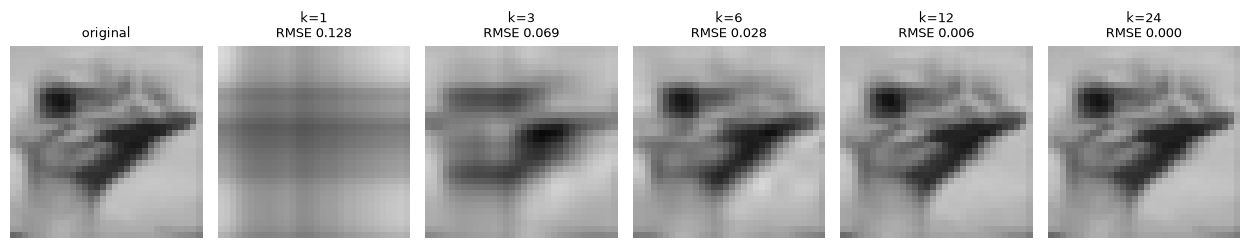

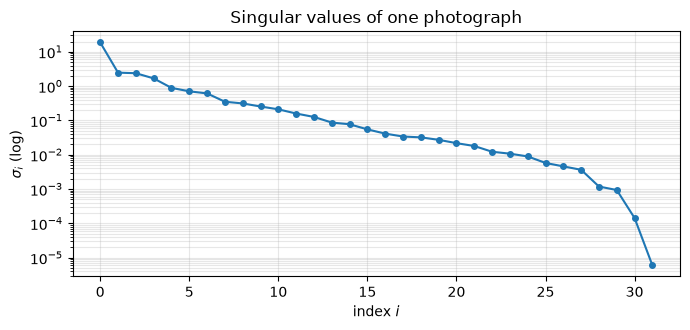

In [6]:
from datasets import load_dataset

cifar = load_dataset("uoft-cs/cifar10")
photo = np.array(cifar["train"][7]["img"], dtype=np.float64).mean(axis=2) / 255.0
m, n = photo.shape

Up, Sp, Vtp = np.linalg.svd(photo, full_matrices=False)
KS = [1, 3, 6, 12, 24]          # <- knob

fig, axes = plt.subplots(1, len(KS) + 1, figsize=(2.1 * (len(KS) + 1), 2.6))
axes[0].imshow(photo, cmap="gray", vmin=0, vmax=1); axes[0].set_title("original", fontsize=9)
axes[0].axis("off")
print(f"{'k':>3} {'RMSE':>8} {'numbers stored':>15} {'vs full image':>14}")
for ax, k in zip(axes[1:], KS):
    rec = truncate(Up, Sp, Vtp, k)
    stored = k * (m + n + 1)
    ax.imshow(np.clip(rec, 0, 1), cmap="gray", vmin=0, vmax=1); ax.axis("off")
    ax.set_title(f"k={k}\nRMSE {np.sqrt(np.mean((rec-photo)**2)):.3f}", fontsize=9)
    print(f"{k:>3} {np.sqrt(np.mean((rec-photo)**2)):>8.4f} {stored:>15} {stored/(m*n):>13.0%}")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.4))
plt.semilogy(Sp, "o-", ms=4)
plt.xlabel("index $i$"); plt.ylabel("$\\sigma_i$ (log)"); plt.grid(alpha=0.3, which="both")
plt.title("Singular values of one photograph"); plt.tight_layout(); plt.show()

**Read the storage column before being impressed by the pictures.** A rank-$k$
approximation of an $m \times n$ image costs $k(m + n + 1)$ numbers, because you
must keep $k$ columns of $U$, $k$ rows of $V^\top$, and $k$ singular values. For
a 32×32 image that breaks even at about $k = 16$, beyond which "compression"
stores *more* than the original.

This is the honest caveat that image-compression demos of the SVD usually skip.
Per-image SVD is a genuinely poor compressor, because the basis has to be
transmitted along with the coefficients. The cosine basis of Chapter 3 wins here
precisely because it is *fixed*: encoder and decoder both already know it, so
only the coefficients cost anything.

Which points at the fix, and at the reason this module is a warm-up rather than
the conclusion: learn **one** basis from **many** images, and amortise its cost
across all of them. That is principal component analysis.

---
# Module V — Principal Component Analysis

## V.a The best basis for a dataset, computed rather than guessed

🧠 **The intuition.** Chapter 2 measured that 500 handwritten threes are
formally 485-dimensional but effectively far smaller. Chapter 3 showed that a
good basis makes most coordinates ignorable, and that the fixed cosine basis
does well on photographs and only modestly well on digits, because it was never
told what it would be describing.

PCA tells it. Centre the data, take the SVD, and the right singular vectors are
the directions of greatest variance, in order: the first captures as much
spread as any single direction can, the second as much of what remains, and so
on. It is the optimal basis for this dataset by construction, which is
Eckart–Young applied to the data matrix.

📐 **The math.** With rows as samples and the mean removed, $X_c = U\Sigma V^\top$:

- **principal directions** = columns of $V$ (eigenvectors of the covariance
  matrix $\frac{1}{n-1}X_c^\top X_c$, which is symmetric, per Chapter 8),
- **variance explained** by direction $i$ = $\sigma_i^2 / \sum_j \sigma_j^2$,
- **scores** (the data in the new coordinates) = $X_c V$.

💻 **The code.**

In [7]:
mnist = load_dataset("ylecun/mnist")
N_TRAIN, N_TEST = 5000, 1000          # <- knobs

def to_matrix(split, n):
    imgs = np.stack([np.array(im, dtype=np.float64) for im in split.select(range(n))["image"]])
    return imgs.reshape(n, -1) / 255.0, np.array(split.select(range(n))["label"])

X_train, y_train = to_matrix(mnist["train"], N_TRAIN)
X_test, y_test = to_matrix(mnist["test"], N_TEST)

mean_digit = X_train.mean(axis=0)
Xc = X_train - mean_digit                              # centring is not optional
Upca, Spca, Vpca = np.linalg.svd(Xc, full_matrices=False)

explained = Spca ** 2 / np.sum(Spca ** 2)
print("data:", X_train.shape, " principal directions:", Vpca.shape[0])
for k in [10, 50, 100, 200]:
    print(f"    first {k:>3} directions explain {explained[:k].sum():.1%} of the variance")

data: (5000, 784)  principal directions: 784
    first  10 directions explain 49.3% of the variance
    first  50 directions explain 82.9% of the variance
    first 100 directions explain 91.8% of the variance
    first 200 directions explain 96.9% of the variance


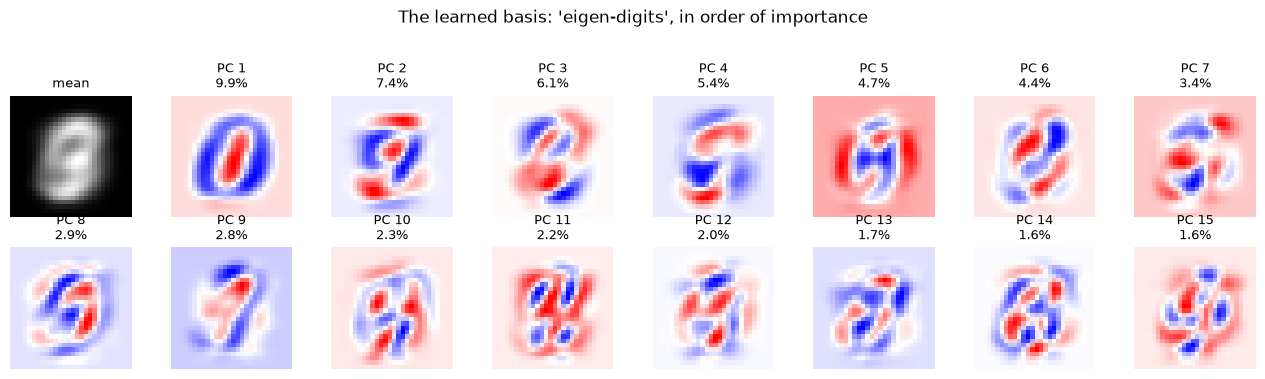

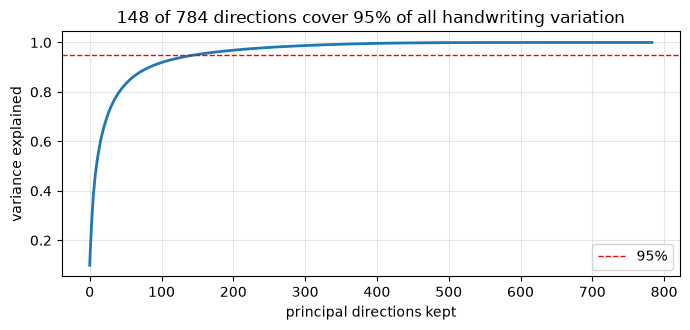

In [8]:
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
axes[0, 0].imshow(mean_digit.reshape(28, 28), cmap="gray")
axes[0, 0].set_title("mean", fontsize=9)
for j in range(1, 8):
    axes[0, j].imshow(Vpca[j - 1].reshape(28, 28), cmap="bwr")
    axes[0, j].set_title(f"PC {j}\n{explained[j-1]:.1%}", fontsize=9)
for j in range(8):
    axes[1, j].imshow(Vpca[j + 7].reshape(28, 28), cmap="bwr")
    axes[1, j].set_title(f"PC {j+8}\n{explained[j+7]:.1%}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("The learned basis: 'eigen-digits', in order of importance", y=1.04)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.4))
plt.plot(np.cumsum(explained), lw=2)
plt.axhline(0.95, color="r", ls="--", lw=1, label="95%")
plt.xlabel("principal directions kept"); plt.ylabel("variance explained")
plt.legend(); plt.grid(alpha=0.3)
plt.title(f"{int(np.searchsorted(np.cumsum(explained), 0.95) + 1)} of 784 directions "
          f"cover 95% of all handwriting variation")
plt.tight_layout(); plt.show()

The first components are not pixels or waves. They are **strokes**: broad
patterns of "ink here, no ink there" that recur across handwriting. They were
not designed, they were measured, and each is labelled with the share of the
dataset's variance it accounts for.

## V.b The showdown promised in Chapter 3

💻 **The code.** Reconstruct **held-out test digits**, images that had no say
in choosing the basis, from $k$ coefficients each, in four bases:

- **PCA**: the first $k$ learned directions (fixed across all images),
- **cosine, fixed**: the $k$ lowest-frequency cosine coefficients, also fixed, which makes this the like-for-like comparison,
- **cosine, adaptive**: the $k$ largest cosine coefficients *chosen per image*, an advantage handed to the cosine basis, since in practice it would also have to record *which* coefficients it kept,
- **pixels**: the $k$ brightest pixels.

In [9]:
def dct_matrix(N):
    u = np.arange(N)[:, None]; x = np.arange(N)[None, :]
    Cm = np.cos((2 * x + 1) * u * np.pi / (2 * N)) * np.sqrt(2.0 / N)
    Cm[0] *= np.sqrt(0.5)
    return Cm

Cd = dct_matrix(28)
test_imgs = X_test.reshape(-1, 28, 28)
cos_coords = Cd @ test_imgs @ Cd.T                      # cosine coordinates of every test image

uu, vv = np.meshgrid(np.arange(28), np.arange(28), indexing="ij")
freq_order = np.argsort((uu + vv).ravel(), kind="stable")     # low frequencies first

def top_k_rows(Cmat, k):
    """Keep the k largest-magnitude entries of each row."""
    out = np.zeros_like(Cmat)
    idx = np.argsort(np.abs(Cmat), axis=1)[:, ::-1][:, :k]
    np.put_along_axis(out, idx, np.take_along_axis(Cmat, idx, axis=1), axis=1)
    return out

rmse = lambda R: np.sqrt(np.mean((R - X_test) ** 2))
results = {"PCA (learned)": [], "cosine, fixed": [], "cosine, adaptive": [], "pixels": []}
KS = [5, 10, 25, 50, 100]        # <- knob

for k in KS:
    pca_rec = (X_test - mean_digit) @ Vpca[:k].T @ Vpca[:k] + mean_digit

    mask = np.zeros(784); mask[freq_order[:k]] = 1.0
    cos_fixed = (Cd.T @ (cos_coords * mask.reshape(28, 28)) @ Cd).reshape(-1, 784)

    cos_adapt = (Cd.T @ top_k_rows(cos_coords.reshape(-1, 784), k).reshape(-1, 28, 28) @ Cd
                 ).reshape(-1, 784)

    pix = top_k_rows(X_test.copy(), k)

    for name, rec in zip(results, [pca_rec, cos_fixed, cos_adapt, pix]):
        results[name].append(rmse(rec))

print(f"{'k':>4}  " + "  ".join(f"{name:>17}" for name in results))
for i, k in enumerate(KS):
    print(f"{k:>4}  " + "  ".join(f"{results[name][i]:>17.4f}" for name in results))
print(f"\nAt k = 25, PCA's error is {results['cosine, fixed'][2]/results['PCA (learned)'][2]:.2f}x "
      f"lower than the fixed cosine basis")
print(f"and still {results['cosine, adaptive'][2]/results['PCA (learned)'][2]:.2f}x lower than the "
      f"adaptive one, which was allowed to pick its coefficients per image.")

   k      PCA (learned)      cosine, fixed   cosine, adaptive             pixels
   5             0.2112             0.2699             0.2382             0.3125
  10             0.1861             0.2564             0.2111             0.3022
  25             0.1453             0.2211             0.1673             0.2697
  50             0.1100             0.1835             0.1288             0.2109
 100             0.0769             0.1334             0.0899             0.1023

At k = 25, PCA's error is 1.52x lower than the fixed cosine basis
and still 1.15x lower than the adaptive one, which was allowed to pick its coefficients per image.


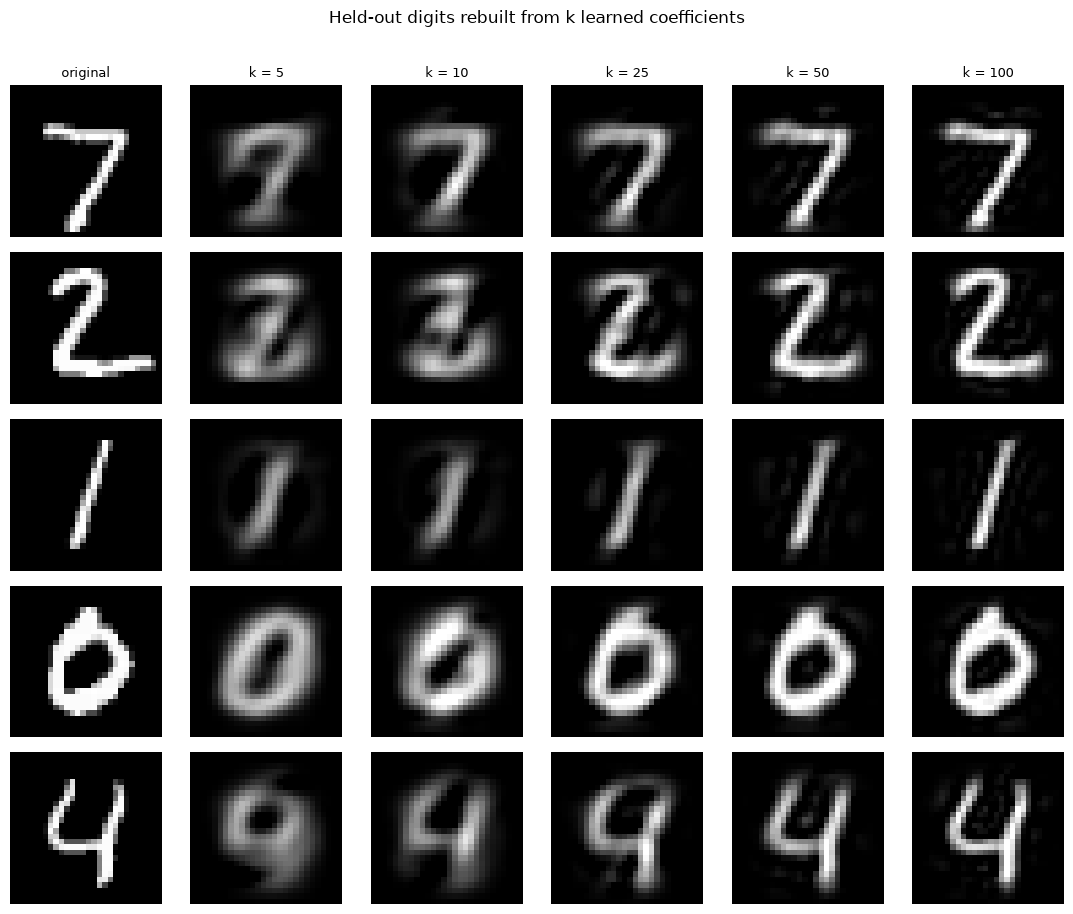

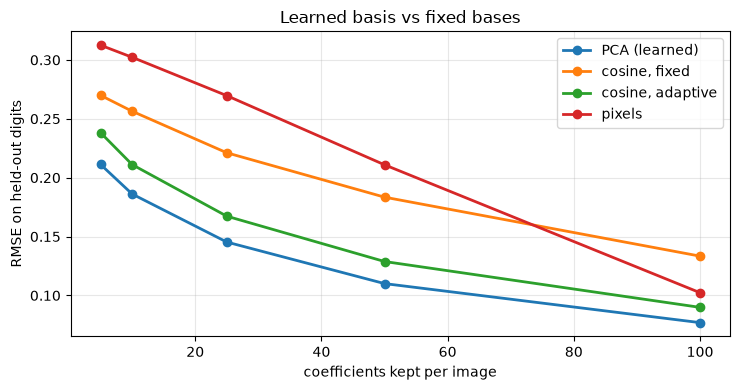

In [10]:
fig, axes = plt.subplots(5, 6, figsize=(11, 9))
which = [0, 1, 2, 3, 4]          # five test digits
for row, idx in enumerate(which):
    axes[row, 0].imshow(X_test[idx].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    if row == 0:
        axes[row, 0].set_title("original", fontsize=9)
    for col, k in enumerate(KS, start=1):
        rec = (X_test[idx] - mean_digit) @ Vpca[:k].T @ Vpca[:k] + mean_digit
        axes[row, col].imshow(np.clip(rec, 0, 1).reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(f"k = {k}", fontsize=9)
for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Held-out digits rebuilt from k learned coefficients", y=1.01)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7.5, 4))
for name, errs in results.items():
    plt.plot(KS, errs, "o-", lw=2, label=name)
plt.xlabel("coefficients kept per image"); plt.ylabel("RMSE on held-out digits")
plt.legend(); plt.grid(alpha=0.3); plt.title("Learned basis vs fixed bases")
plt.tight_layout(); plt.show()

**The promise made in Chapter 3 is kept, and it is worth being precise about the
size of the win.** The learned basis beats the fixed cosine basis at every
budget, but by a factor of roughly 1.3–1.7 in RMSE, not by an order of magnitude.
It even beats the *adaptive* cosine basis, which was allowed to choose different
coefficients for every image while PCA used the same $k$ directions for all of
them, an advantage PCA gave away and still won.

Two honest limitations belong next to that result. PCA is **linear**: it finds
the best flat subspace, and Chapter 1 already measured that digits do not lie on
a flat one, since the 3-to-8 blend came out as a double exposure rather than a
digit. Reconstructions at small $k$ are blurry for exactly that reason. PCA also
optimises **squared error, not recognisability**, so it will happily spend its
budget on a smooth grey haze if that is what minimises the metric.

## V.c Two coordinates are enough to see structure

Project every test digit onto just the first two principal directions and plot
the result. Nothing here was told about the labels. The colours are added
afterwards, purely to see whether the geometry found the classes on its own.

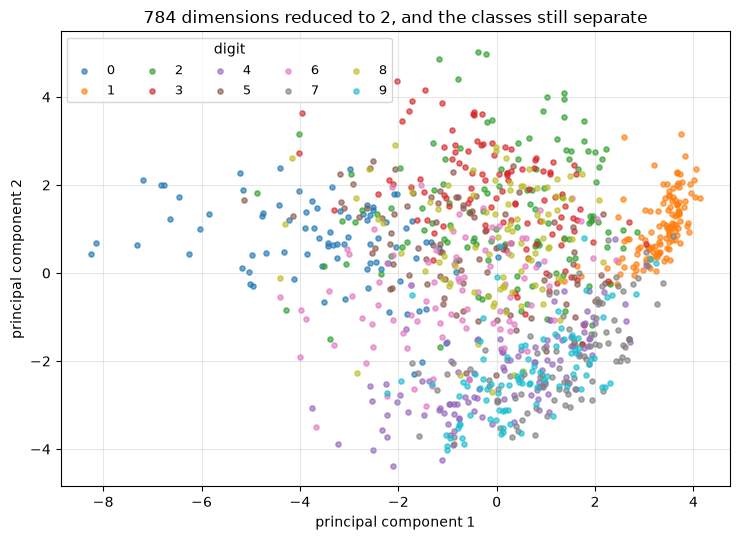

Each point is an entire 28x28 image, described by two numbers.

mean PC1 score by digit: {0: -3.46, 1: 3.3, 2: 0.13, 3: 0.01, 4: 0.14, 5: -0.68, 6: -0.93, 7: 1.3, 8: -0.09, 9: 0.58}
    extremes: 0 at -3.46 and 1 at 3.30

correlation between PC1 and total ink in the image: -0.795


In [11]:
scores = (X_test - mean_digit) @ Vpca[:2].T          # every test digit in 2 numbers

plt.figure(figsize=(7.5, 5.5))
for d in range(10):
    sel = y_test == d
    plt.scatter(scores[sel, 0], scores[sel, 1], s=14, alpha=0.65, label=str(d))
plt.xlabel("principal component 1"); plt.ylabel("principal component 2")
plt.legend(ncol=5, fontsize=9, title="digit"); plt.grid(alpha=0.3)
plt.title("784 dimensions reduced to 2, and the classes still separate")
plt.tight_layout(); plt.show()

print("Each point is an entire 28x28 image, described by two numbers.\n")
means = {d: scores[y_test == d, 0].mean() for d in range(10)}
lo, hi = min(means, key=means.get), max(means, key=means.get)
print("mean PC1 score by digit:", {d: round(float(v), 2) for d, v in means.items()})
print(f"    extremes: {lo} at {means[lo]:.2f} and {hi} at {means[hi]:.2f}")
print(f"\ncorrelation between PC1 and total ink in the image: "
      f"{np.corrcoef(scores[:, 0], X_test.sum(axis=1))[0, 1]:.3f}")

The classes are not cleanly separated, since two numbers cannot do that, but the
structure is unmistakable, and the algorithm was never shown a single label.

The printed numbers say what the first direction actually captured: 0s sit at one
extreme and 1s at the other, and PC1 correlates about $-0.8$ with the total
amount of ink in the image. A 0 is a large loop and a 1 is a thin stroke, so the
single most useful thing to know about a handwritten digit, measured rather than
assumed, turns out to be roughly *how much of it there is*.

---
# Module VI — The Pseudo-Inverse: Least Squares That Never Breaks

🧠 **The intuition.** Chapter 7 solved least squares with $(A^\top A)^{-1}A^\top$,
which needs independent columns, and Chapter 6 warned that inverting is fragile.
The SVD gives a version with no preconditions at all: invert what is invertible,
and leave the rest alone.

📐 **The math.** The **Moore–Penrose pseudo-inverse** is

$$ A^+ = V\Sigma^+U^\top, \qquad \Sigma^+ = \text{diag}(1/\sigma_1, \dots, 1/\sigma_r, 0, \dots, 0) $$

Reciprocate the non-zero singular values, and put zeros where $\sigma_i = 0$.
Then $\hat{\mathbf{x}} = A^+\mathbf{b}$ is:

- the exact solution, when one exists and is unique;
- the least-squares solution, when the system is overdetermined (Chapter 7);
- and among infinitely many solutions, the one with **smallest norm**, when the
  system is underdetermined.

💻 **The code.** A rank-deficient least-squares problem, the case where the
normal equations simply fail.

In [12]:
Ad = np.column_stack([np.array([1.0, 1.0, 0.0, 2.0]),
                      np.array([2.0, 2.0, 0.0, 4.0]),          # exactly 2x the first column
                      np.array([0.0, 1.0, 1.0, 0.0])])
bd = np.array([1.0, 2.0, 3.0, 1.0])

print("rank of A:", np.linalg.matrix_rank(Ad), "of 3 columns -> A^T A is singular")
try:
    np.linalg.solve(Ad.T @ Ad, Ad.T @ bd)
except np.linalg.LinAlgError as exc:
    print("normal equations:", type(exc).__name__, "-", exc)

Us, Ss, Vts = np.linalg.svd(Ad, full_matrices=False)
S_plus = np.array([1 / s if s > 1e-10 else 0.0 for s in Ss])
A_plus = Vts.T @ np.diag(S_plus) @ Us.T
x_pinv = A_plus @ bd

print("\npseudo-inverse solution :", np.round(x_pinv, 6))
print("np.linalg.pinv           :", np.round(np.linalg.pinv(Ad) @ bd, 6))
print("np.linalg.lstsq          :", np.round(np.linalg.lstsq(Ad, bd, rcond=None)[0], 6))
print(f"\nresidual ||Ax - b|| = {np.linalg.norm(Ad @ x_pinv - bd):.6f}")
print("residual ⊥ column space:", np.round(Ad.T @ (Ad @ x_pinv - bd), 10))

# among all least-squares solutions, this one has the smallest norm
null_dir = Vts[-1] if np.min(Ss) < 1e-10 else np.zeros(3)
print(f"\n||x_pinv|| = {np.linalg.norm(x_pinv):.6f}")
for t in [0.5, -0.5, 2.0]:
    alt = x_pinv + t * null_dir
    print(f"    x + {t:>4}·(null direction): same residual "
          f"{np.linalg.norm(Ad @ alt - bd):.6f}, but larger norm {np.linalg.norm(alt):.6f}")

rank of A: 2 of 3 columns -> A^T A is singular
normal equations: LinAlgError - Singular matrix

pseudo-inverse solution : [0.091 0.182 2.273]
np.linalg.pinv           : [0.091 0.182 2.273]
np.linalg.lstsq          : [0.091 0.182 2.273]

residual ||Ax - b|| = 1.167748
residual ⊥ column space: [0. 0. 0.]

||x_pinv|| = 2.281800
    x +  0.5·(null direction): same residual 1.167748, but larger norm 2.335939
    x + -0.5·(null direction): same residual 1.167748, but larger norm 2.335939
    x +  2.0·(null direction): same residual 1.167748, but larger norm 3.034240


---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| The circle → ellipse sequence | Every matrix is rotate–stretch–rotate. No shape restrictions, no defective cases |
| `svd_from_scratch` via `eigh(AᵀA)` | The SVD is the spectral theorem, applied to a symmetric matrix you can always build |
| Rank, $\kappa$, $\|A\|_2$, and all four subspaces from $U, \Sigma, V$ | One factorisation answers nearly every question the course has asked |
| Truncation beating 5,000 random rank-4 matrices | **Eckart–Young**: truncated SVD is provably optimal, and its error is known in advance |
| $k(m+n+1)$ storage accounting | Per-image SVD is a bad compressor. Count what you store before claiming a win |
| Eigen-digits and explained variance | The optimal basis for a dataset is *measured*, not designed |
| PCA beating the cosine basis by ~1.3–1.7× | Learned beats fixed, but by a factor rather than an order of magnitude. Report the size of the win |
| Ten digit classes separating in 2 coordinates | Dimensionality reduction is Chapter 3's change of basis, with the basis chosen by the data |
| $A^+ = V\Sigma^+U^\top$ | Invert what is invertible, zero the rest: least squares with no preconditions |

---

## The course, in one page

You began with a definition that refused to say what a vector *is*, and that
refusal has paid for everything since.

| Chapter | The question | The answer |
|---|---|---|
| 1 | What is a vector? | Anything you can add and scale, including polynomials, functions, and images |
| 2 | What can a set of vectors reach, and is any of it redundant? | Span and linear independence |
| 3 | What is the minimal description of a space? | A basis, which turns vectors into coordinates and makes the choice of description yours |
| 4 | What is a matrix? | A linear transformation, written in a chosen basis; its columns are where the basis vectors land |
| 5 | When can we solve $A\mathbf{x} = \mathbf{b}$? | Compare rank, $\text{rank}[A\mid\mathbf{b}]$, and $n$; the answer lives in the four subspaces |
| 6 | When can a map be undone? | When it destroys no volume, though what you measure is conditioning rather than the determinant |
| 7 | What if there is no solution? | Project onto the column space: least squares is a right angle |
| 8 | Is there a basis where a square matrix is simple? | Its eigenvectors, guaranteed orthogonal when the matrix is symmetric |
| 9 | Is there one for *every* matrix, and for data? | The SVD, and its data-driven form, PCA |

Three habits are worth carrying forward more than any single theorem:

1. **The column view.** $A\mathbf{x}$ is a combination of columns. Almost every
   confusing formula in the subject becomes readable through it.
2. **Definition ≠ algorithm.** Cofactor determinants, characteristic
   polynomials, normal equations, $A^{-1}\mathbf{b}$, $A^\top A$: each is the
   clearest way to *state* something and the wrong way to *compute* it.
3. **Measure the claim.** Every number in these nine notebooks was computed, not
   asserted, and several of them came out smaller than the story usually told:
   the cosine basis barely helps on digits, PCA beats it by a factor rather than
   an order of magnitude, and 500 handwritten threes are neither independent nor
   as high-dimensional as their 784 pixels suggest.